In [1]:
from mpi4py import MPI
import numpy as np
from dolfinx import mesh, fem
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

In [2]:
REAL_NX, REAL_NY, REAL_NZ = 60, 220, 85
FT_TO_M = 0.3048

REAL_LX = REAL_NX * 20 * FT_TO_M 
REAL_LY = REAL_NY * 10 * FT_TO_M 

def load_and_scale_kq(path, max_scale = 10.0):
    kq_layer = np.load(path) 
    
    log_kq = np.log10(kq_layer + 1e-6)

    l_min, l_max = log_kq.min(), log_kq.max()
    k_scaled = (log_kq - l_min) / (l_max - l_min) * (max_scale - 1.0) + 1.0
    scale = (1.0, max_scale)
    
    return k_scaled, scale

kq_data_matrix, scale = load_and_scale_kq('/mnt/c/PINN_mgr/FEniCS/solver-validation-newton-method/data/spe_model2_layer50.npy', max_scale=10.0)

x_coords = np.linspace(0, REAL_LX, REAL_NX)
y_coords = np.linspace(0, REAL_LY, REAL_NY)

interp_kq = RegularGridInterpolator((y_coords, x_coords), kq_data_matrix, 
                                    bounds_error=False, fill_value=1.0)


Path("results/fields").mkdir(parents=True, exist_ok=True)
Path("results/metrics").mkdir(parents=True, exist_ok=True)


domain = mesh.create_rectangle(MPI.COMM_WORLD, 
                               [np.array([0, 0]), np.array([REAL_LX, REAL_LY])], 
                               [REAL_NX, REAL_NY])

V = fem.functionspace(domain, ("Lagrange", 1))

Kq = fem.Function(V)
def kq_map(x):
    pts = np.stack((x[1], x[0]), axis=-1) 
    return interp_kq(pts)

Kq.interpolate(kq_map) 

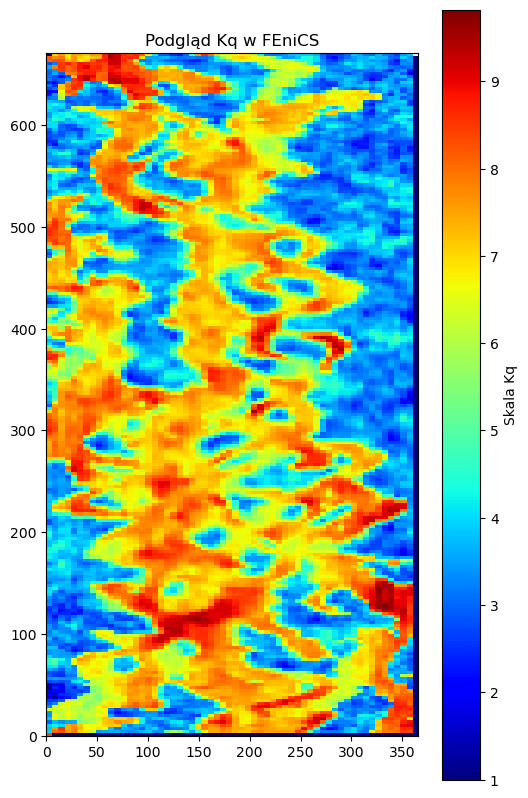

In [3]:
if MPI.COMM_WORLD.rank == 0:
    coords = V.tabulate_dof_coordinates()
    vals = Kq.x.array 

    xi = np.linspace(0, REAL_LX, REAL_NX)
    yi = np.linspace(0, REAL_LY, REAL_NY)
    Xi, Yi = np.meshgrid(xi, yi)

    from scipy.interpolate import griddata
    Kq_check = griddata(coords[:, :2], vals, (Xi, Yi), method='linear')

    plt.figure(figsize=(6, 10))
    plt.imshow(Kq_check, extent=[0, REAL_LX, 0, REAL_LY], cmap='jet', origin='lower')
    plt.colorbar(label="Skala Kq")
    plt.title("Podgląd Kq w FEniCS")
    plt.show() 